# Bank Marketing Campaign - Funnel & Conversion Analysis
This notebook analyses a bank marketing campaign dataset to understand how customers move through the funnel from contact to subscription, and where drop-offs occur.

**Name:** Tshegofatso Chikwane

## Import Libraries

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Inspect the Data
We load the CSV file and check its shape, columns and first few rows.

In [113]:
# LOAD AND INSPECT THE DATA

In [114]:
df = pd.read_csv('bank-full.csv', sep=';')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: 45211 rows, 17 columns

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [115]:
print("Data types:")
df.dtypes

Data types:


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [116]:
df.head(5)  # shows the top 5 rows

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [117]:
df.tail(5)  # shows the bottom 5 rows

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [118]:
df.info()   # shows variables and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## 2. Check for Missing Values
Missing values are empty cells. We need to find them before cleaning.

In [119]:
missing = df.isnull().sum()  # checking for missing values

print("Missing Values per column:")
missing[missing > 0]

Missing Values per column:


Series([], dtype: int64)

## 3. Check for Duplicates
Duplicate rows are exact copies of each other. They skew our results so we remove them.

In [120]:
# checking for duplicates
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [121]:
# basic stats
basic_stats = df.describe()

print("Basic Stats:")
basic_stats

Basic Stats:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 4. Data Cleaning
We rename columns for clarity, convert the target variable to binary, and create useful funnel stage columns.

In [122]:
# remove duplicates
df = df.drop_duplicates()

In [123]:
# rename target column for clarity
df = df.rename(columns={'y': 'Subscribed'})

In [124]:
# convert Subscribed to binary for calculations
df['Subscribed_Binary'] = df['Subscribed'].map({'yes': 1, 'no': 0})

In [125]:
# create age groups for segmentation
df['Age Group'] = pd.cut(df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['Under 25', '25-34', '35-44', '45-54', '55-64', '65+'])

In [126]:
# create campaign contact groups
df['Campaign Group'] = pd.cut(df['campaign'],
    bins=[0, 1, 3, 5, 10, 100],
    labels=['1 contact', '2-3 contacts', '4-5 contacts', '6-10 contacts', '10+ contacts'])

In [127]:
# check rows remaining after data cleaning
print("\nAFTER DATA CLEANING")
print("Rows remaining:", len(df))
print("New columns added: Subscribed_Binary, Age Group, Campaign Group")


AFTER DATA CLEANING
Rows remaining: 45211
New columns added: Subscribed_Binary, Age Group, Campaign Group


In [128]:
# key funnel metrics
total = len(df)
converted = df['Subscribed_Binary'].sum()
print("\n--- KEY FUNNEL METRICS ---")
print(f"Total Contacts:       {total:,}")
print(f"Total Conversions:    {converted:,}")
print(f"Total Non-Converted:  {total - converted:,}")
print(f"Overall Conversion Rate: {(converted/total*100):.2f}%")
print(f"Avg Call Duration:    {df['duration'].mean():.0f} seconds")
print(f"Avg Contacts per Campaign: {df['campaign'].mean():.1f}")


--- KEY FUNNEL METRICS ---
Total Contacts:       45,211
Total Conversions:    5,289
Total Non-Converted:  39,922
Overall Conversion Rate: 11.70%
Avg Call Duration:    258 seconds
Avg Contacts per Campaign: 2.8


In [129]:
# conversion by contact channel
print("\n--- CONVERSION RATE BY CONTACT CHANNEL ---")
print(df.groupby('contact')['Subscribed_Binary'].mean().mul(100).round(2).astype(str) + '%')


--- CONVERSION RATE BY CONTACT CHANNEL ---
contact
cellular     14.92%
telephone    13.42%
unknown       4.07%
Name: Subscribed_Binary, dtype: object


In [130]:
# conversion by job
print("\n--- CONVERSION RATE BY JOB ---")
print(df.groupby('job')['Subscribed_Binary'].mean().mul(100).round(2).sort_values(ascending=False).astype(str) + '%')


--- CONVERSION RATE BY JOB ---
job
student          28.68%
retired          22.79%
unemployed        15.5%
management       13.76%
admin.            12.2%
self-employed    11.84%
unknown          11.81%
technician       11.06%
services          8.88%
housemaid         8.79%
entrepreneur      8.27%
blue-collar       7.27%
Name: Subscribed_Binary, dtype: object


In [131]:
# conversion by month
print("\n--- CONVERSION RATE BY MONTH ---")
print(df.groupby('month')['Subscribed_Binary'].mean().mul(100).round(2).astype(str) + '%')


--- CONVERSION RATE BY MONTH ---
month
apr    19.68%
aug    11.01%
dec    46.73%
feb    16.65%
jan    10.12%
jul     9.09%
jun    10.22%
mar    51.99%
may     6.72%
nov    10.15%
oct    43.77%
sep    46.46%
Name: Subscribed_Binary, dtype: object


## 5. Visualizations
Now that the data is clean, we explore the funnel using different types of charts.

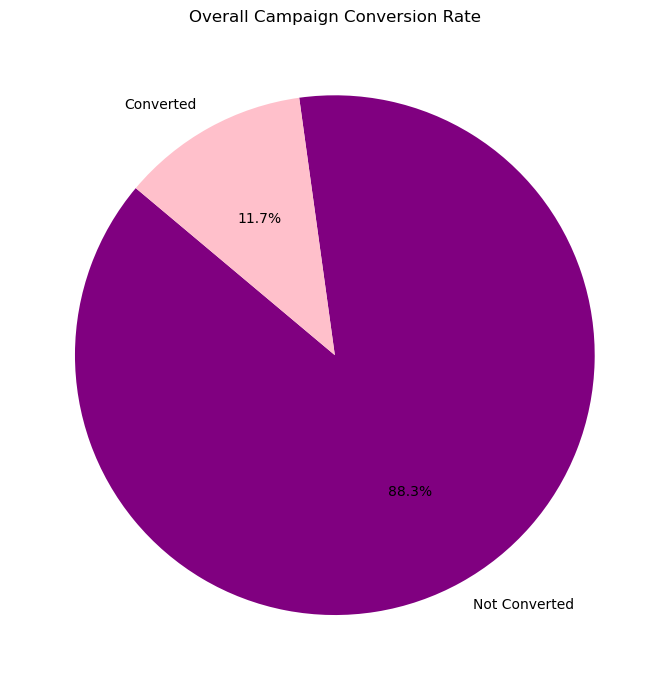

In [132]:
# Chart 1: Overall Conversion Distribution - PIE CHART
conversion_counts = df['Subscribed'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(conversion_counts.values, labels=['Not Converted', 'Converted'],
        autopct='%1.1f%%',
        colors=['purple', 'pink'],
        startangle=140)
plt.title('Overall Campaign Conversion Rate')
plt.tight_layout()
plt.show()

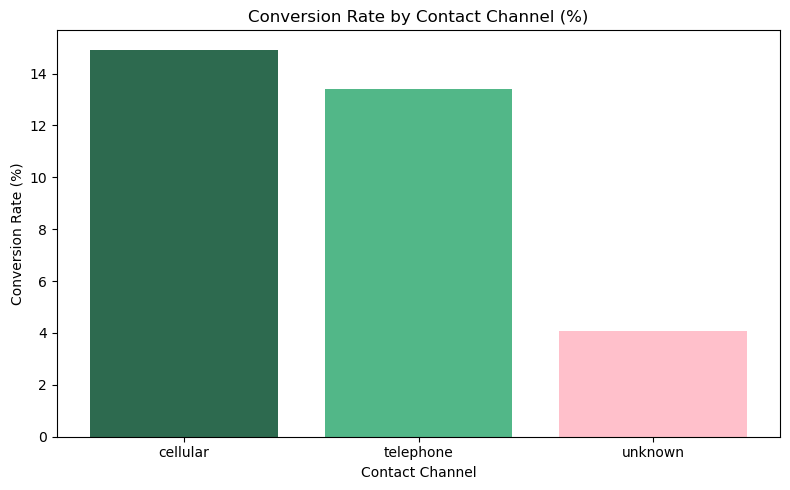

In [133]:
# Chart 2: Conversion Rate by Contact Channel - BAR CHART
channel_conv = df.groupby('contact')['Subscribed_Binary'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(channel_conv.index, channel_conv.values, color=['#2d6a4f', '#52b788', 'pink'])
plt.title('Conversion Rate by Contact Channel (%)')
plt.xlabel('Contact Channel')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

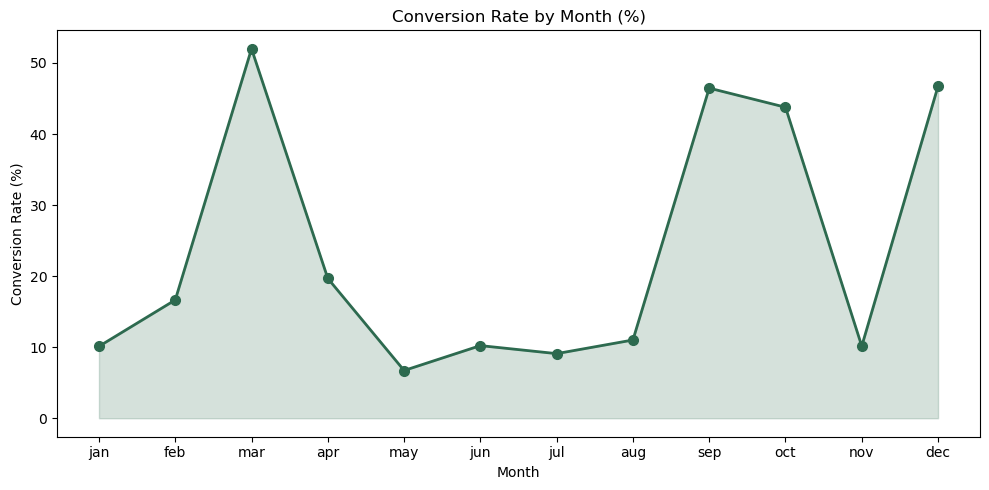

In [134]:
# Chart 3: Conversion Rate by Month - LINE CHART
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
monthly_conv = df.groupby('month')['Subscribed_Binary'].mean().mul(100).reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(monthly_conv.index, monthly_conv.values, color='#2d6a4f', marker='o', linewidth=2, markersize=7)
plt.fill_between(range(len(monthly_conv)), monthly_conv.values, alpha=0.2, color='#2d6a4f')
plt.title('Conversion Rate by Month (%)')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

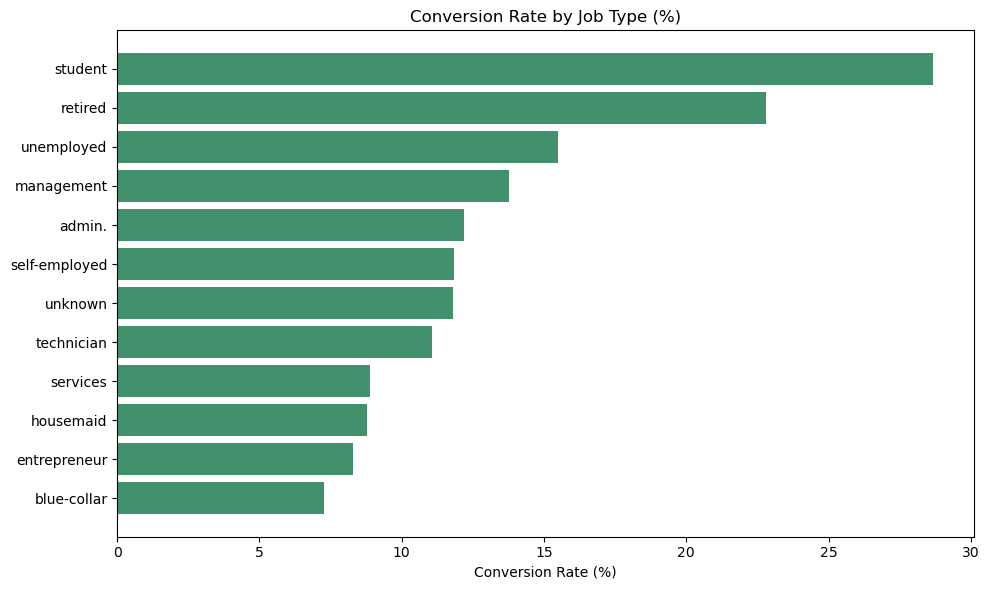

In [135]:
# Chart 4: Conversion Rate by Job - HORIZONTAL BAR CHART
job_conv = df.groupby('job')['Subscribed_Binary'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(job_conv.index[::-1], job_conv.values[::-1], color='#40916c')
plt.title('Conversion Rate by Job Type (%)')
plt.xlabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

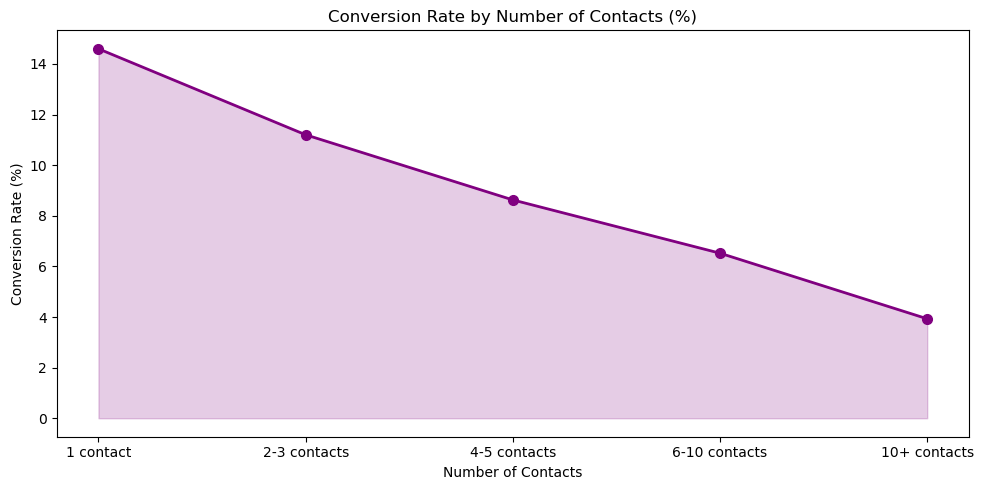

In [136]:
# Chart 5: Conversion Rate by Number of Contacts - LINE CHART
campaign_conv = df.groupby('Campaign Group')['Subscribed_Binary'].mean().mul(100)

plt.figure(figsize=(10, 5))
plt.plot(campaign_conv.index.astype(str), campaign_conv.values, color='purple', marker='o', linewidth=2, markersize=7)
plt.fill_between(range(len(campaign_conv)), campaign_conv.values, alpha=0.2, color='purple')
plt.title('Conversion Rate by Number of Contacts (%)')
plt.xlabel('Number of Contacts')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

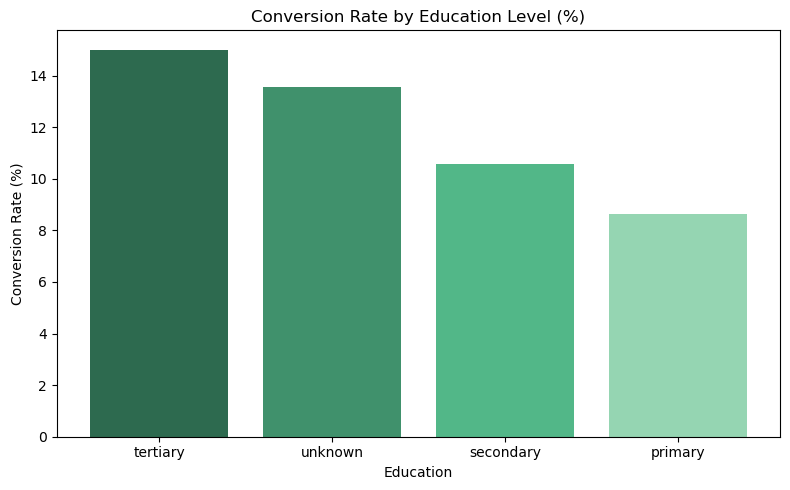

In [137]:
# Chart 6: Conversion Rate by Education - BAR CHART
edu_conv = df.groupby('education')['Subscribed_Binary'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(edu_conv.index, edu_conv.values, color=['#2d6a4f','#40916c','#52b788','#95d5b2'])
plt.title('Conversion Rate by Education Level (%)')
plt.xlabel('Education')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

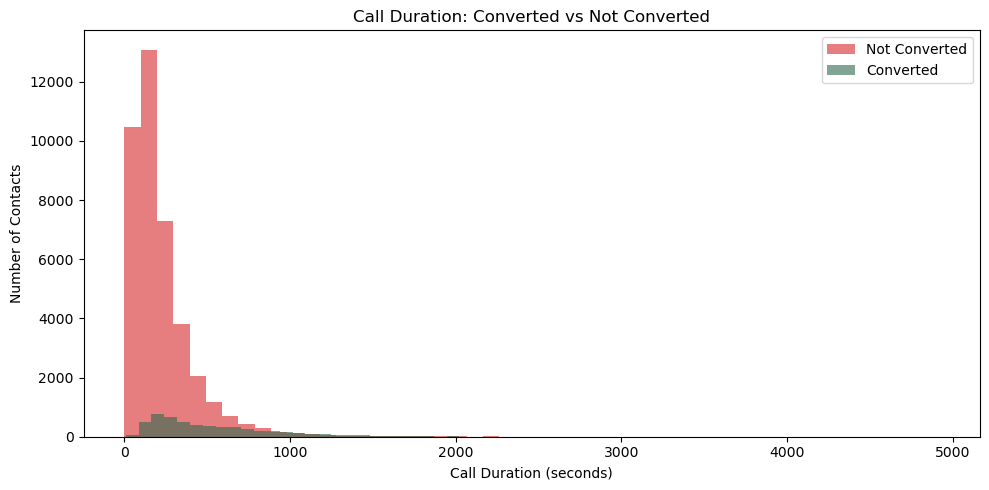

In [138]:
# Chart 7: Call Duration - Converted vs Not Converted - HISTOGRAM
plt.figure(figsize=(10, 5))
plt.hist(df[df['Subscribed'] == 'no']['duration'], bins=50, alpha=0.6, color='#d62728', label='Not Converted')
plt.hist(df[df['Subscribed'] == 'yes']['duration'], bins=50, alpha=0.6, color='#2d6a4f', label='Converted')
plt.title('Call Duration: Converted vs Not Converted')
plt.xlabel('Call Duration (seconds)')
plt.ylabel('Number of Contacts')
plt.legend()
plt.tight_layout()
plt.show()

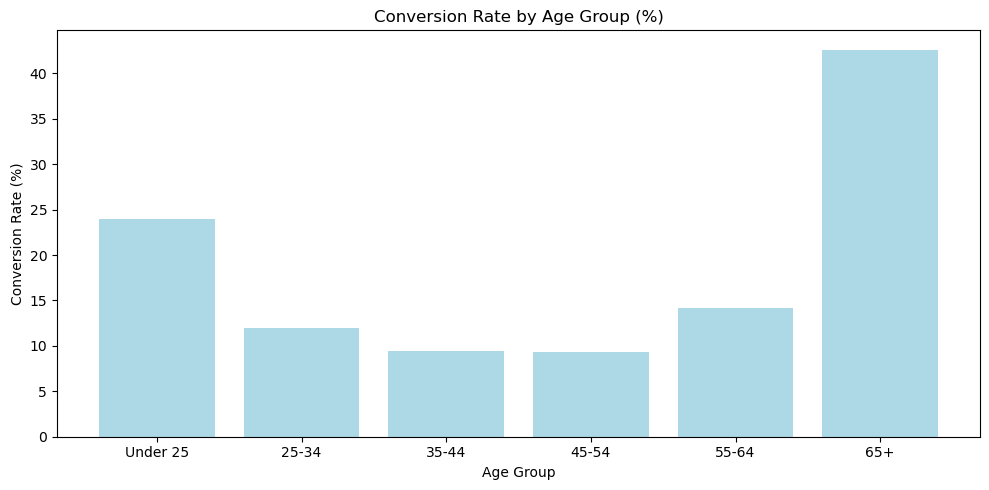

In [139]:
# Chart 8: Conversion Rate by Age Group - BAR CHART
age_conv = df.groupby('Age Group')['Subscribed_Binary'].mean().mul(100)

plt.figure(figsize=(10, 5))
plt.bar(age_conv.index.astype(str), age_conv.values, color='lightblue')
plt.title('Conversion Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

## 6. Save the Clean Data
We save the cleaned dataset as a new CSV file for future use.

In [140]:
# save clean data
df.to_csv('bank_funnel_clean.csv', index=False)
print("Clean data saved as bank_funnel_clean.csv")

Clean data saved as bank_funnel_clean.csv
